# Age Gender Distortion Assignment

Assignment conducted by: **Negi Hoxha(p3352524)**

Firstly I have choose the 3 csv files that we need for this assignemt
`GTP2-large-dimensions` , `experiment_control`, `experiment_treatment`.

--------------------------------------------------------------------------------------------------------------------------------------------------------

Before we start with the tasks we installing and import the necessary libaries 

P.S: This assignment was written in VS Code. You may need to make a small change at this point: if you are running it in JupyterLab, replace ! with %.

In [ ]:
!py -m pip install pandas numpy matplotlib seaborn plotly statsmodels scipy pingouin

In [5]:
import pandas as pd
import numpy as np
import pingouin as pg
from statsmodels.stats.power import NormalIndPower
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.patches import Patch
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats

 

-----------------------------------------------------------------------------------------------

### Pearson Correlation Summary

This cell defines a helper function, `correlation_summary`, which computes a comprehensive statistical summary of the linear association between two variables using Pearson’s correlation coefficient.

#### Data handling
- The analysis is based on complete cases only.
- The effective sample size (*n*) is determined after pairwise deletion of missing values.

#### Effect size and inference
- The Pearson correlation coefficient (*r*) and its two-sided *p*-value are computed using `pingouin.corr`.
- A 95% confidence interval for *r* is obtained via Fisher’s *z* transformation, as implemented internally by `pingouin`.

#### Bayesian evidence
- Evidence for the alternative hypothesis (*H₁*: non-zero correlation) is quantified using the Bayes factor **BF₁₀**.
- The Bayes factor is computed with `pingouin.bayesfactor_pearson`, which uses a Jeffreys–Zellner–Siow (JZS) prior.
- Values of BF₁₀ > 1 indicate evidence in favor of *H₁*, while values < 1 favor the null hypothesis.

#### Statistical power
- Post-hoc (observed) power is estimated using a normal approximation on the Fisher-*z* scale.
- The calculation is performed with `statsmodels.stats.power.NormalIndPower`, treating the Fisher-transformed correlation as the effect size.

#### Output
The function returns a dictionary containing:
- `n`: effective sample size  
- `r`: Pearson correlation coefficient  
- `CI95%`: 95% confidence interval for *r*  
- `p-val`: two-sided *p*-value  
- `BF10`: Bayes factor in favor of the alternative hypothesis  
- `power`: estimated statistical power at α = 0.05


In [6]:
def correlation_summary(x, y, alpha: float=0.05):
    res = pg.corr(x, y, method='pearson')
    n = int(res['n'][0])
    r = float(res['r'][0])

    bf10 = pg.bayesfactor_pearson(r, n)

    power = NormalIndPower().power(
        effect_size=np.arctanh(r),
        nobs1=n,
        alpha=alpha
    )

    return {
        "n": n,
        "r": r,
        "CI95%": res['CI95%'][0],
        "p-val": res['p-val'][0],
        "BF10": bf10,
        "power": power,
    }

### Correlation Results

Pearson’s correlation was computed between **age.main** and **gender.main** using the data from `GPT2-large-dimensions.csv`.  
The table below reports the effective sample size (*n*), correlation coefficient (*r*), 95% confidence interval, two-sided *p*-value, Bayes factor (BF₁₀), and estimated post-hoc power (α = 0.05).

The row label *“pearson”* indicates that all statistics correspond to Pearson’s correlation coefficient.


In [7]:
dimensions = pd.read_csv("GPT2-large-dimensions.csv")

summary = correlation_summary(dimensions["age.main"].values,
                              dimensions["gender.main"].values)

result_table = pd.DataFrame(
    {
        "n":      [summary["n"]],
        "r":      [summary["r"]],
        "CI95%":  [summary["CI95%"]],
        "p-val":  [summary["p-val"]],
        "BF10":   [summary["BF10"]],
        "power":  [summary["power"]],
    },
    index=["pearson"],
)

result_table


C:\Users\negi_\AppData\Local\Temp\ipykernel_15860\1973561932.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n = int(res['n'][0])
C:\Users\negi_\AppData\Local\Temp\ipykernel_15860\1973561932.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r = float(res['r'][0])
C:\Users\negi_\AppData\Local\Temp\ipykernel_15860\1973561932.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "CI95%": res['CI95%'][0],
C:\Users\negi_\AppData\Loc

,n,r,CI95%,p-val,BF10,power
pearson,3495,0.872559,"[0.86, 0.88]",0.0,inf,1.0


--------------------------------------------------------------------------------------

### Within-Dimension Correlations

This cell computes Pearson correlation matrices for the three age-related variables  
(*age.red*, *age.ext*, *age.main*) and the three gender-related variables  
(*gender.red*, *gender.ext*, *gender.main*).

The resulting correlation matrices are visualized as heatmaps, where each cell shows
the pairwise correlation coefficient. Color intensity reflects the strength of the
association, with darker shades indicating higher correlations.


In [8]:
age_cols_src    = ["age.red",    "age.ext",    "age.main"]
gender_cols_src = ["gender.red", "gender.ext", "gender.main"]

age_labels    = ["age_red", "age_ext", "age_score"]
gender_labels = ["gender_red", "gender_ext", "gender_score"]

age_mat    = dimensions[age_cols_src].to_numpy(float)
gender_mat = dimensions[gender_cols_src].to_numpy(float)

corr_age    = np.corrcoef(age_mat, rowvar=False)
corr_gender = np.corrcoef(gender_mat, rowvar=False)


def plot_heatmap(matrix: np.ndarray, labels, title: str):
    fig, ax = plt.subplots(figsize=(5, 4))
    cax = ax.imshow(matrix, cmap="Reds", vmin=0.6, vmax=1.0)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center", color="black")

    ax.set_title(title)
    fig.colorbar(cax, ax=ax)
    plt.tight_layout()
    plt.show()


The following heatmaps visualize the Pearson correlation matrices for the age-related
and gender-related variables, respectively. Each cell displays the pairwise correlation
coefficient between dimensions, with darker colors indicating stronger associations.


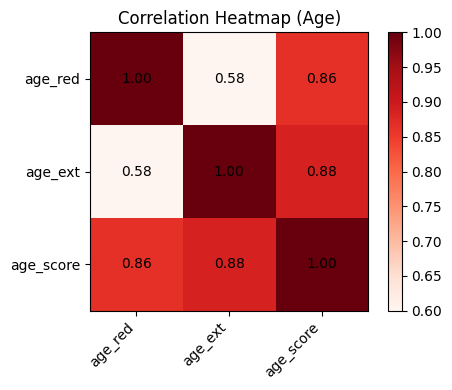

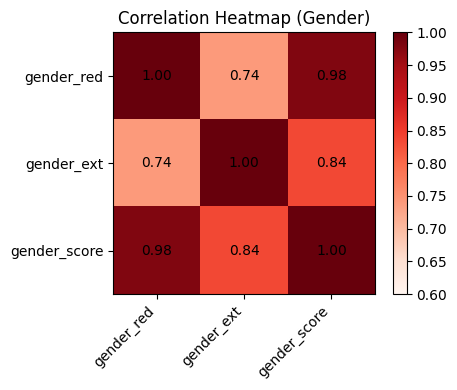

In [9]:
plot_heatmap(corr_age, age_labels, "Correlation Heatmap (Age)")
plot_heatmap(corr_gender, gender_labels, "Correlation Heatmap (Gender)")


---------------------------------------------------------

### Linear Regression Analysis

This cell fits an ordinary least squares (OLS) regression model predicting
**age_norm_main** from **gender_norm_main**. The model summary reports the estimated
regression coefficient, standard errors, test statistics, and overall model fit.


In [10]:
df = dimensions.rename(columns={
    'age_norm.main': 'age_norm_main',
    'gender_norm.main': 'gender_norm_main'
})

formula = 'age_norm_main ~ gender_norm_main'

model = smf.ols(formula, data=df).fit()
model.model.data.ynames = "age_norm_main"

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          age_norm_main   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                 1.114e+04
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:22:16   Log-Likelihood:                 5425.6
No. Observations:                3495   AIC:                        -1.085e+04
Df Residuals:                    3493   BIC:                        -1.083e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0211      0.003     -6.510      0.000      -0.027      -0.015
gender_norm_main     0.7450      0.007    105.565      0.000       0.731       0.759
==============================================================================
Omnibus:                      829.901   Durbin-Watson:                   1.255
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4643.267
Skew:                           1.012   Prob(JB):                         0.00
Kurtosis:                       8.271   Cond. No.                         9.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

------------------------------------------------------------------------------------------------

### Data Preparation and Category Highlighting

This cell selects **gender.main** and **age.main** as the variables of interest,
coerces them to numeric values, and removes rows with missing data. It also defines
a subset of social categories to be highlighted in subsequent analyses by creating
a boolean indicator based on the **Social.Category** column.


In [11]:
x_col = "gender.main"
y_col = "age.main"
label_col = "Social.Category"

dimensions[x_col] = pd.to_numeric(dimensions[x_col], errors="coerce")
dimensions[y_col] = pd.to_numeric(dimensions[y_col], errors="coerce")
df = dimensions.dropna(subset=[x_col, y_col]).copy()

highlight_categories = [
    "chairman of the board",
    "elected official",
    "military personnel",
    "director of research",
    "chief of staff",
    "secretary",
    "intern",
    "cook",
    "novice",
    "homeopath",
]

df["highlight"] = df[label_col].isin(highlight_categories)

### Scatter Plot with Highlighted Categories

This figure shows the relationship between **gender.main** and **age.main** as a scatter plot.
All observations are displayed in the background, along with a fitted linear regression line.
Selected social categories are highlighted and annotated to emphasize their positions relative
to the overall trend.


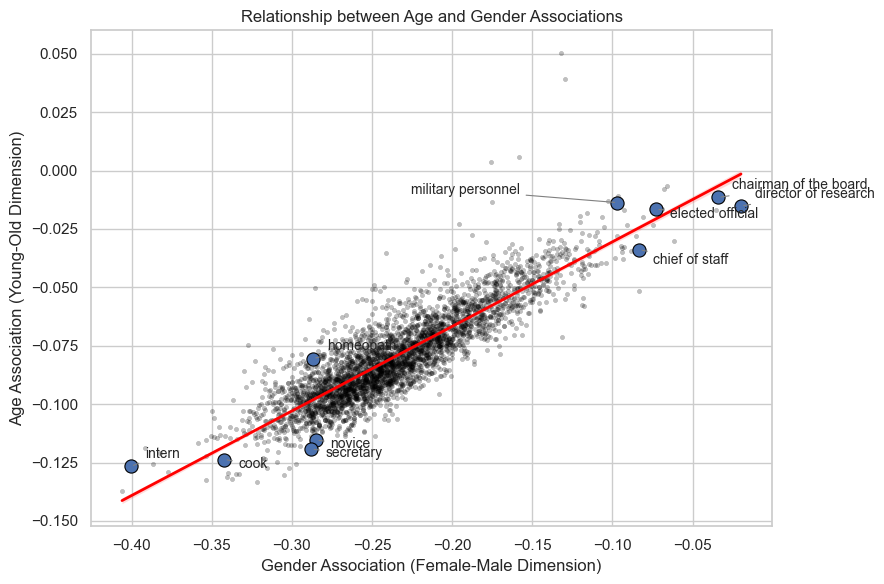

In [12]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x=x_col, y=y_col,
    color="black",
    s=10,
    alpha=0.25,
    edgecolor=None,
    zorder=1,
    ax=ax
)

sns.regplot(
    data=df,
    x=x_col, y=y_col,
    scatter=False,
    color="red",
    line_kws={"linewidth": 2, "zorder": 2},  
    ax=ax
)

sns.scatterplot(
    data=df[df["highlight"]],
    x=x_col, y=y_col,
    s=90,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
    ax=ax
)

label_offsets = {
    "chairman of the board": (10, 6),
    "elected official": (10, -6),
    "military personnel": (-70, 6),
    "director of research": (10, 6),
    "chief of staff": (10, -10),
    "secretary": (10, -6),
    "intern": (10, 6),
    "cook": (10, -6),
    "novice": (10, -6),
    "homeopath": (10, 6),
}

for _, r in df[df["highlight"]].iterrows():
    dx, dy = label_offsets.get(r[label_col], (8, 8))
    ax.annotate(
        r[label_col],
        xy=(r[x_col], r[y_col]),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="left" if dx >= 0 else "right",
        fontsize=10,
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.8,
            color="gray"
        ),
        zorder=4
    )

ax.set_title("Relationship between Age and Gender Associations")
ax.set_xlabel("Gender Association (Female-Male Dimension)")
ax.set_ylabel("Age Association (Young-Old Dimension)")

plt.tight_layout()
plt.show()


### Interactive Scatter Plot (Plotly)

This cell recreates the previous Age–Gender scatter plot as an **interactive Plotly figure**.
Points show **gender.main** vs **age.main**, with hover tooltips displaying the corresponding
**Social.Category** and numeric values. An OLS trend line is added for the overall relationship,
and the predefined highlighted categories are overlaid with larger markers and text labels.


In [13]:
fig = px.scatter(
    df,
    x=x_col,
    y=y_col,
    hover_name=label_col,
    hover_data={x_col:":.3f", y_col:":.3f", "highlight": False},
    opacity=0.35,
)

fig.update_traces(marker=dict(size=5), selector=dict(mode="markers"))

m, b = np.polyfit(df[x_col].to_numpy(), df[y_col].to_numpy(), 1)
x_line = np.linspace(df[x_col].min(), df[x_col].max(), 200)
y_line = m * x_line + b

fig.add_scatter(
    x=x_line,
    y=y_line,
    mode="lines",
    line=dict(color="red", width=2),
    name="OLS fit",
)


hi = df[df["highlight"]].copy()

fig.add_scatter(
    x=hi[x_col],
    y=hi[y_col],
    mode="markers+text",
    text=hi[label_col],
    textposition="top left",
    marker=dict(size=10),
    name="Highlighted categories",
)

fig.update_layout(
    title="Relationship between Age and Gender Associations",
    xaxis_title="Gender Association (Female-Male Dimension)",
    yaxis_title="Age Association (Young-Old Dimension)",
    template="plotly_white",
    width=850,
    height=550,
)

fig

-----------------------------------------------------

### Treatment–Control Difference Computation

This cell loads the control and treatment datasets, computes category-level mean age
in the control condition, and merges it with the treatment data. An age difference
score (*age_diff*) is then calculated for each subject as the deviation from the
corresponding control mean. The data are restricted to Female and Male groups and
split accordingly for downstream comparisons.


In [14]:
control = pd.read_csv("experiment_control.csv")
treat   = pd.read_csv("experiment_treatment.csv")

control_mean = (
    control.groupby("category", as_index=False)["age"]
    .mean()
    .rename(columns={"age": "age_control_mean"})
)

df = (
    treat.merge(control_mean, on="category", how="left")
         .assign(age_diff=lambda d: d["age"] - d["age_control_mean"])
         .loc[
             lambda d: d["gender"].isin(["Female", "Male"]),
             ["subj", "category", "gender", "age", "age_control_mean", "age_diff"]
         ]
)

female = df.loc[df["gender"].eq("Female"), "age_diff"].dropna()
male   = df.loc[df["gender"].eq("Male"),   "age_diff"].dropna()

### Distribution of Treatment–Control Age Differences

This figure shows kernel density estimates of the age difference scores (*age_diff*)
for Female and Male groups. Shaded densities represent the distributions, solid
vertical lines indicate group means, and the dashed line at zero marks no difference
from the control condition.


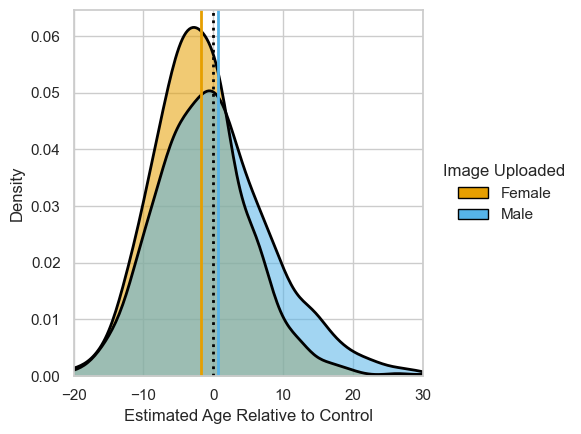

In [15]:
female_color = "#E69F00"
male_color   = "#56B4E9"

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.kdeplot(female, ax=ax, fill=True, color=female_color, alpha=0.55,
            linewidth=0, clip=(-20, 30), cut=0)
sns.kdeplot(male,   ax=ax, fill=True, color=male_color,   alpha=0.55,
            linewidth=0, clip=(-20, 30), cut=0)

sns.kdeplot(female, ax=ax, color="black", linewidth=2, clip=(-20, 30), cut=0)
sns.kdeplot(male,   ax=ax, color="black", linewidth=2, clip=(-20, 30), cut=0)

ax.axvline(0, color="black", linestyle=":", linewidth=2)

female_mean = female.mean()
male_mean   = male.mean()
ax.axvline(female_mean, color=female_color, linestyle="-", linewidth=2)
ax.axvline(male_mean,   color=male_color,   linestyle="-", linewidth=2)

ax.set_xlim(-20, 30)
ax.set_xticks([-20, -10, 0, 10, 20, 30])
ax.set_xlabel("Estimated Age Relative to Control")
ax.set_ylabel("Density")

handles = [
    Patch(facecolor=female_color, edgecolor="black", label="Female"),
    Patch(facecolor=male_color,   edgecolor="black", label="Male"),
]
ax.legend(handles=handles, title="Image Uploaded", frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

### Statistical Tests of Age Differences

This cell performs one-sample *t*-tests to assess whether the mean age difference
(*age_diff*) differs from zero for Female and Male groups separately. A Welch
two-sample *t*-test is then used to compare the mean age differences between
Female and Male groups. Reported values include group means, *t* statistics,
and formatted two-sided *p*-values.


In [16]:
def p_fmt(p):
    if p < 0.0005:
        return "< 0.001"
    else:
        return f"= {p:.4f}"

t_female = stats.ttest_1samp(female, popmean=0, nan_policy="omit")
t_male   = stats.ttest_1samp(male,   popmean=0, nan_policy="omit")
t_male_vs_female = stats.ttest_ind(male, female, equal_var=False, nan_policy="omit")
female_diff = female.mean()
male_diff   = male.mean()
male_female_diff = male.mean() - female.mean()
print(
    f"Female vs Control: mean = {female.mean():.2f}, "
    f"t = {t_female.statistic:.2f}, p {p_fmt(t_female.pvalue)}"
)

print(
    f"Male vs Control: mean = {male.mean():.2f}, "
    f"t = {t_male.statistic:.2f}, p {p_fmt(t_male.pvalue)}"
)

print(
    f"Female vs Male: mean = {(female.mean() - male.mean()):.2f}, "
    f"t = {-t_male_vs_female.statistic:.2f}, p {p_fmt(t_male_vs_female.pvalue)}"
)


Female vs Control: mean = -1.75, t = -11.32, p < 0.001
Male vs Control: mean = 0.64, t = 3.42, p = 0.0006
Female vs Male: mean = -2.39, t = -9.84, p < 0.001


------------------------------------------------------------------------------------

### Combined Dataset Preparation

This cell concatenates the treatment and control datasets, retains observations
from Male and Female groups, and enforces categorical encoding for gender, condition,
category, and subject identifiers. Rows with missing values in key variables are
removed to produce a clean dataset for subsequent analyses.


In [17]:
df = pd.concat([treat, control], ignore_index=True)

df = df[df["gender"].isin(["Male", "Female"])].copy()

df["gender"] = pd.Categorical(df["gender"], categories=["Male", "Female"])
df["condition"] = pd.Categorical(df["condition"], categories=["Control", "Image"])

df["category"] = df["category"].astype("category")
df["subj"] = df["subj"].astype("category")

df = df.dropna(subset=["age", "condition", "gender", "category", "subj"]).copy()

### Linear Model with Condition and Gender Interaction

This cell fits an OLS regression model predicting **age** from experimental
**condition** (Image vs Control) and **gender**, including their interaction.
Category and subject are included as additional fixed effects to account for
systematic differences across stimuli and participants. The model summary
reports coefficient estimates, statistical tests, and overall fit.


In [18]:
formula = (
    'age ~ C(condition, Treatment(reference="Control"))'
    ' * C(gender, Treatment(reference="Male"))'
    ' + category + subj'
)

model = smf.ols(formula, data=df).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     22.30
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:22:20   Log-Likelihood:                -28066.
No. Observations:                8514   AIC:                         5.715e+04
Df Residuals:                    8005   BIC:                         6.074e+04
Df Model:                         508                                         
Covariance Type:            nonrobust                                         
                                                                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

-----------------------------------------------------

### Baseline Adjustment and Residual Aggregation

This cell fits a baseline OLS model predicting **age** from category and subject
effects only. Predicted values and residuals are then computed for each observation
and summarized by experimental condition and gender, yielding mean estimates and
standard errors for both baseline predictions and residualized age scores.


In [19]:
baseline_model = smf.ols(
    "age ~ category + subj",
    data=df
).fit()

df["age_pred"] = baseline_model.predict(df)
df["residual"] = df["age"] - df["age_pred"]

grouped = (
    df
    .groupby(["condition", "gender"])
    .agg(
        pred_mean=("age_pred", "mean"),
        pred_se=("age_pred", lambda x: x.std() / (len(x) ** 0.5)),
        res_mean=("residual", "mean"),
        res_se=("residual", lambda x: x.std() / (len(x) ** 0.5)),
    )
    .reset_index()
)


C:\Users\negi_\AppData\Local\Temp\ipykernel_15860\1781175379.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



### Predicted Values and Residualized Effects by Condition and Gender

These figures display group-level means with standard error bars for Female and Male
participants across experimental conditions. The first plot shows baseline-predicted
age values, while the second plot shows residualized age scores after removing
category and subject effects.


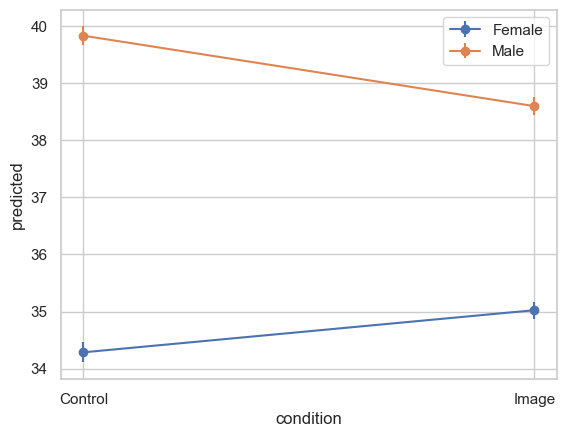

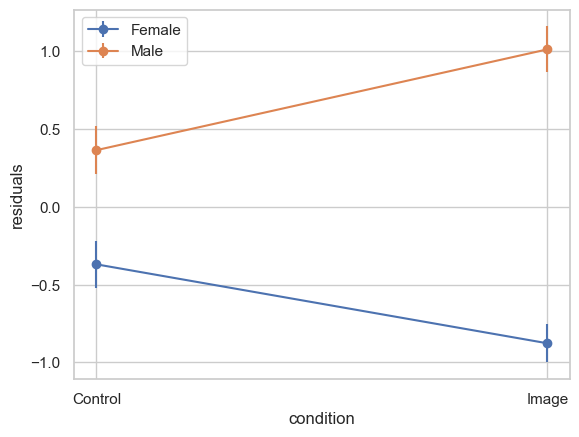

In [20]:
fig, ax = plt.subplots()

for gender in ["Female", "Male"]:
    sub = grouped[grouped["gender"] == gender]
    ax.errorbar(
        sub["condition"],
        sub["pred_mean"],
        yerr=sub["pred_se"],
        marker="o",
        label=gender
    )

ax.set_xlabel("condition")
ax.set_ylabel("predicted")
ax.legend()

plt.show()

fig, ax = plt.subplots()

for gender in ["Female", "Male"]:
    sub = grouped[grouped["gender"] == gender]
    ax.errorbar(
        sub["condition"],
        sub["res_mean"],
        yerr=sub["res_se"],
        marker="o",
        label=gender
    )

ax.set_xlabel("condition")
ax.set_ylabel("residuals")
ax.legend()

plt.show()


----------------------------------------------------------------------------------------

### Two-Way ANOVA with Condition and Gender

This cell fits a two-way ANOVA model testing the main effects of experimental
**condition** and **gender**, as well as their interaction, on **age** using
sum-to-zero contrasts. The resulting ANOVA table reports Type II sums of squares
and corresponding *F* tests.


In [21]:
anova_model_1 = smf.ols(
    "age ~ C(condition, Sum) * C(gender, Sum)",
    data=df
).fit()

anova_table_1 = anova_lm(anova_model_1, typ=2)

anova_table_1

,sum_sq,df,F,PR(>F)
"C(condition, Sum)",57.586138,1.0,0.607880,4.356088e-01
"C(gender, Sum)",71856.913990,1.0,758.522619,5.017108e-160
"C(condition, Sum):C(gender, Sum)",347.367889,1.0,3.666820,5.553946e-02
Residual,806175.481608,8510.0,NaN,NaN


### Two-Way ANOVA with Covariate Adjustment

This cell extends the two-way ANOVA by including **category** and **subject**
as additional fixed effects. The model tests the main effects of experimental
**condition** and **gender**, as well as their interaction, while adjusting for
systematic differences across categories and participants. Type II sums of squares
are reported.


In [22]:
anova_model_2 = smf.ols(
    "age ~ C(condition, Sum) * C(gender, Sum) + category + subj",
    data=df
).fit()

anova_table_2 = anova_lm(anova_model_2, typ=2)

anova_table_2


,sum_sq,df,F,PR(>F)
"C(condition, Sum)",620.352248,1.0,13.649851,2.217273e-04
"C(gender, Sum)",8055.025507,1.0,177.237846,5.166031e-40
category,230669.638586,53.0,95.764404,0.000000e+00
subj,456023.489313,453.0,22.150246,0.000000e+00
"C(condition, Sum):C(gender, Sum)",329.073698,1.0,7.240736,7.141576e-03
Residual,363807.622227,8005.0,NaN,NaN
